<a href="https://colab.research.google.com/github/edwardaohewitt2000-sudo/Mathematical-Modelling-Portfolio/blob/main/Boiling_crisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

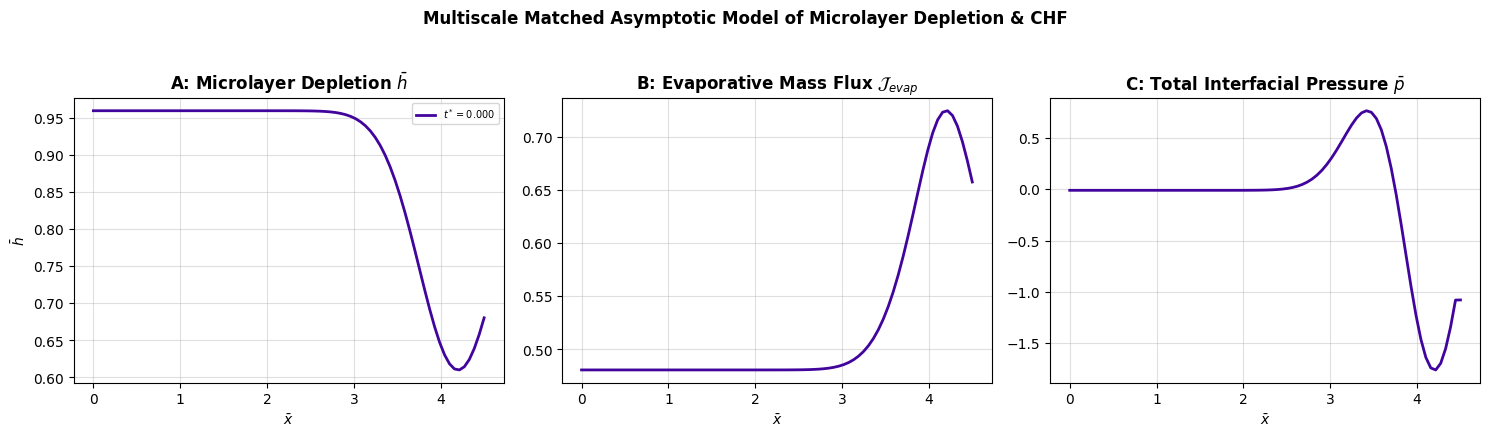

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def solve_3scale_chf_robust(
    Nx=80,                # Spatial nodes
    L_x=4.5,              # Non-dimensional domain size
    t_final=0.03,         # Simulation run time
    E=0.5,                # Evaporative number
    K_star=0.08,          # Kinetic thermal resistance
    R_recoil=0.04         # Recoil parameter
):
    # Spatial discretization
    x = np.linspace(0, L_x, Nx)
    dx = x[1] - x[0]
    H_e = 0.05  # Physical adsorbed film floor limit

    # Initial smooth microlayer profile
    h0 = 0.96 - 0.35 * np.exp(-((x - 4.2)**2) / 0.4)
    h0 = np.maximum(h0, H_e)

    # Stiff PDE Right-Hand Side Evaluation
    def rhs(t, h_vec):
        h_curr = np.maximum(h_vec, H_e)

        # 1. Interfacial Curvature
        d2h = np.zeros(Nx)
        d2h[1:-1] = (h_curr[2:] - 2*h_curr[1:-1] + h_curr[:-2]) / (dx**2)
        d2h[0] = d2h[1]; d2h[-1] = d2h[-2]

        # 2. Local Evaporation & Vapor Recoil Pressure
        j_evap = E / (h_curr + K_star)
        p = -d2h - R_recoil * (j_evap**2)

        # 3. Interfacial Pressure Gradient
        dp_dx = np.zeros(Nx)
        dp_dx[1:-1] = (p[2:] - p[:-2]) / (2 * dx)
        dp_dx[0] = (p[1] - p[0]) / dx
        dp_dx[-1] = (p[-1] - p[-2]) / dx

        # 4. Viscous Hydrodynamic Mass Flux
        flux = (h_curr**3 / 3.0) * dp_dx
        div_flux = np.zeros(Nx)
        div_flux[1:-1] = (flux[2:] - flux[:-2]) / (2 * dx)

        # 5. Mass Conservation Time Derivative
        dh_dt = -div_flux - j_evap
        dh_dt[0] = dh_dt[1]
        dh_dt[-1] = -j_evap[-1]

        return dh_dt

    # Solve via Radau / BDF stiff adaptive integrator
    t_eval = np.linspace(0, t_final, 5)
    sol = solve_ivp(rhs, (0, t_final), h0, method='Radau', t_eval=t_eval, rtol=1e-4, atol=1e-6)

    # Extract profiles
    h_hist = [sol.y[:, i] for i in range(len(sol.t))]
    j_hist = [E / (sol.y[:, i] + K_star) for i in range(len(sol.t))]

    p_hist = []
    for i in range(len(sol.t)):
        h_c = sol.y[:, i]
        d2h = np.zeros(Nx)
        d2h[1:-1] = (h_c[2:] - 2*h_c[1:-1] + h_c[:-2]) / (dx**2)
        d2h[0] = d2h[1]; d2h[-1] = d2h[-2]
        p_val = -d2h - R_recoil * (E / (h_c + K_star))**2
        p_hist.append(p_val)

    return x, sol.t, h_hist, j_hist, p_hist

# Run robust solver
x_bar, times, h_hist, j_hist, p_hist = solve_3scale_chf_robust()

# Render visual dashboard
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=100)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(times)))

for i in range(len(times)):
    axes[0].plot(x_bar, h_hist[i], label=f'$t^*={times[i]:.3f}$', color=colors[i], lw=2)
    axes[1].plot(x_bar, j_hist[i], color=colors[i], lw=2)
    axes[2].plot(x_bar, p_hist[i], color=colors[i], lw=2)

axes[0].set_title("A: Microlayer Depletion $\\bar{h}$", fontweight='bold')
axes[0].set_xlabel("$\\bar{x}$"); axes[0].set_ylabel("$\\bar{h}$")
axes[0].grid(True, alpha=0.4); axes[0].legend(fontsize=7)

axes[1].set_title("B: Evaporative Mass Flux $\\mathcal{J}_{evap}$", fontweight='bold')
axes[1].set_xlabel("$\\bar{x}$"); axes[1].grid(True, alpha=0.4)

axes[2].set_title("C: Total Interfacial Pressure $\\bar{p}$", fontweight='bold')
axes[2].set_xlabel("$\\bar{x}$"); axes[2].grid(True, alpha=0.4)

plt.suptitle("Multiscale Matched Asymptotic Model of Microlayer Depletion & CHF", fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

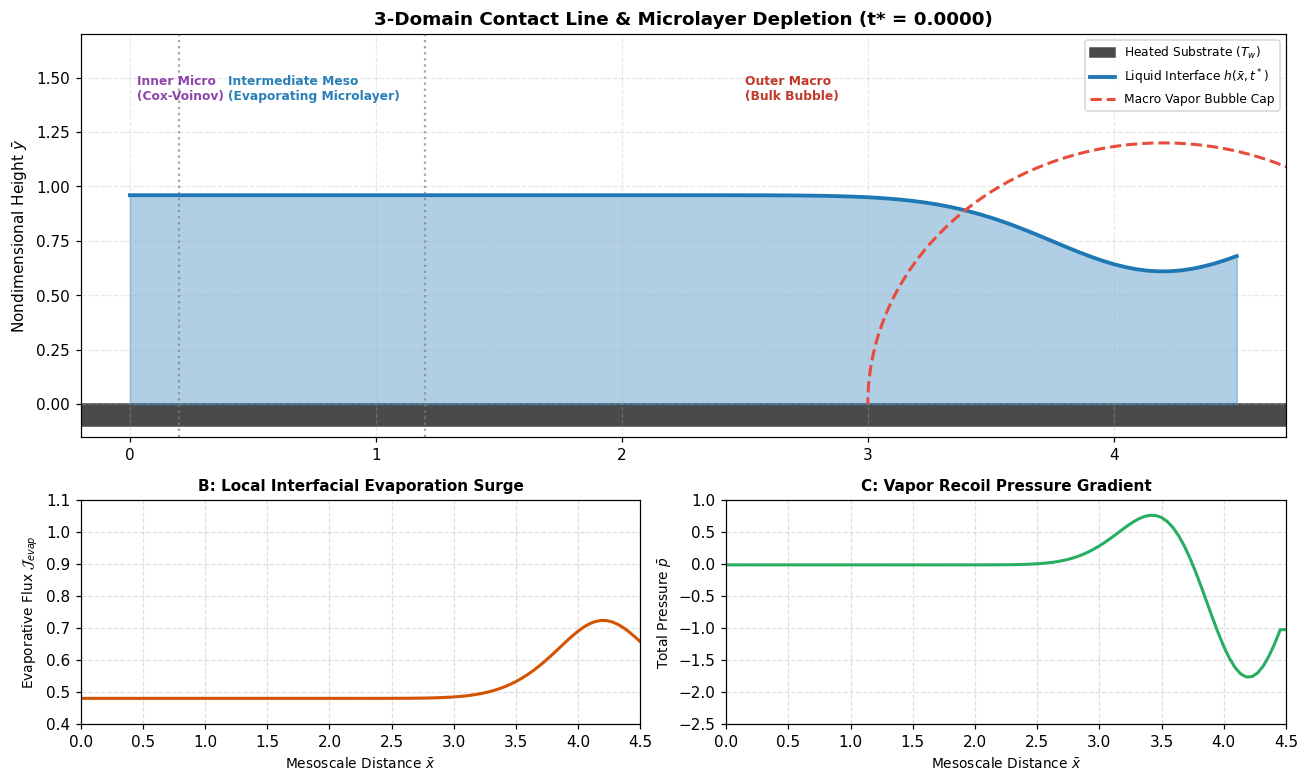

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.integrate import solve_ivp

# ==============================================================================
# 1. SPATIAL DOMAIN & PHYSICAL PARAMETERS
# ==============================================================================
Nx = 100
L_x = 4.5
x = np.linspace(0, L_x, Nx)
dx = x[1] - x[0]

E = 0.5
K_star = 0.08
R_recoil = 0.04
H_e = 0.05  # Equilibrium adsorbed film floor limit

# Initial film thickness profile h_bar(x_bar, 0)
h0 = 0.96 - 0.35 * np.exp(-((x - 4.2)**2) / 0.4)
h0 = np.maximum(h0, H_e)

# ==============================================================================
# 2. STIFF PDE RIGHT-HAND SIDE EVALUATION
# ==============================================================================
def rhs(t, h_vec):
    h_curr = np.maximum(h_vec, H_e)

    # Curvature (2nd spatial derivative)
    d2h = np.zeros(Nx)
    d2h[1:-1] = (h_curr[2:] - 2*h_curr[1:-1] + h_curr[:-2]) / (dx**2)
    d2h[0] = d2h[1]; d2h[-1] = d2h[-2]

    # Interfacial Mass Evaporation & Vapor Recoil
    j_evap = E / (h_curr + K_star)
    p = -d2h - R_recoil * (j_evap**2)

    # Interfacial Pressure Gradient
    dp_dx = np.zeros(Nx)
    dp_dx[1:-1] = (p[2:] - p[:-2]) / (2 * dx)
    dp_dx[0] = (p[1] - p[0]) / dx; dp_dx[-1] = (p[-1] - p[-2]) / dx

    # Viscous Hydrodynamic Mass Flux
    flux = (h_curr**3 / 3.0) * dp_dx
    div_flux = np.zeros(Nx)
    div_flux[1:-1] = (flux[2:] - flux[:-2]) / (2 * dx)

    # Mass Conservation Equation: dh/dt = - div(flux) - j_evap
    dh_dt = -div_flux - j_evap
    dh_dt[0] = dh_dt[1]
    dh_dt[-1] = -j_evap[-1]

    return dh_dt

# Solve system robustly across 60 evaluation frames
t_final = 0.035
n_frames = 60
t_eval = np.linspace(0, t_final, n_frames)

sol = solve_ivp(
    rhs,
    (0, t_final),
    h0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-4,
    atol=1e-6,
    max_step=0.001
)

# Fallback check to ensure all frames are populated
if sol.y.shape[1] < n_frames:
    t_eval = np.linspace(0, sol.t[-1], n_frames)
    sol_y_interp = np.zeros((Nx, n_frames))
    for i in range(Nx):
        sol_y_interp[i, :] = np.interp(t_eval, sol.t, sol.y[i, :])
    sol_t = t_eval
    sol_y = sol_y_interp
else:
    sol_t = sol.t
    sol_y = sol.y

# ==============================================================================
# 3. MULTI-DOMAIN ANIMATION ARCHITECTURE
# ==============================================================================
fig = plt.figure(figsize=(12, 7), dpi=110)
gs = fig.add_gridspec(2, 2, height_ratios=[1.8, 1], width_ratios=[1, 1])

ax_physical = fig.add_subplot(gs[0, :])
ax_flux = fig.add_subplot(gs[1, 0])
ax_pressure = fig.add_subplot(gs[1, 1])

# Upper Plot: Physical Domain Representation
ax_physical.fill_between([-0.5, L_x + 0.5], -0.1, 0, color='#4A4A4A', hatch='//', label=r'Heated Substrate ($T_w$)')

line_film, = ax_physical.plot([], [], color='#1f77b4', lw=2.5, label=r'Liquid Interface $h(\bar{x}, t^*)$')
fill_liquid = ax_physical.fill_between([], [], color='#1f77b4', alpha=0.35)

theta = np.linspace(0, np.pi, 100)
R_bubble_init = 1.2
x_bubble_center = 4.2
line_bubble, = ax_physical.plot([], [], color='#e74c3c', lw=2, linestyle='--', label='Macro Vapor Bubble Cap')

ax_physical.axvline(x=0.2, color='gray', linestyle=':', alpha=0.7)
ax_physical.axvline(x=1.2, color='gray', linestyle=':', alpha=0.7)
ax_physical.text(0.03, 1.4, 'Inner Micro\n(Cox-Voinov)', fontsize=8, fontweight='bold', color='#8e44ad')
ax_physical.text(0.4, 1.4, 'Intermediate Meso\n(Evaporating Microlayer)', fontsize=8, fontweight='bold', color='#2980b9')
ax_physical.text(2.5, 1.4, 'Outer Macro\n(Bulk Bubble)', fontsize=8, fontweight='bold', color='#c0392b')

ax_physical.set_xlim(-0.2, L_x + 0.2)
ax_physical.set_ylim(-0.15, 1.7)
ax_physical.set_ylabel(r'Nondimensional Height $\bar{y}$', fontsize=10)
ax_physical.legend(loc='upper right', fontsize=8)
ax_physical.grid(True, linestyle='--', alpha=0.3)

# Lower Plots
line_flux, = ax_flux.plot([], [], color='#d35400', lw=2)
ax_flux.set_xlim(0, L_x)
ax_flux.set_ylim(0.4, 1.1)
ax_flux.set_xlabel(r'Mesoscale Distance $\bar{x}$', fontsize=9)
ax_flux.set_ylabel(r'Evaporative Flux $\mathcal{J}_{evap}$', fontsize=9)
ax_flux.set_title(r'B: Local Interfacial Evaporation Surge', fontsize=10, fontweight='bold')
ax_flux.grid(True, linestyle='--', alpha=0.4)

line_pressure, = ax_pressure.plot([], [], color='#27ae60', lw=2)
ax_pressure.set_xlim(0, L_x)
ax_pressure.set_ylim(-2.5, 1.0)
ax_pressure.set_xlabel(r'Mesoscale Distance $\bar{x}$', fontsize=9)
ax_pressure.set_ylabel(r'Total Pressure $\bar{p}$', fontsize=9)
ax_pressure.set_title(r'C: Vapor Recoil Pressure Gradient', fontsize=10, fontweight='bold')
ax_pressure.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

# ==============================================================================
# 4. ANIMATION UPDATE FUNCTION
# ==============================================================================
def update(frame):
    global fill_liquid
    t_curr = sol_t[frame]
    h_curr = sol_y[:, frame]
    j_curr = E / (h_curr + K_star)

    # Compute Pressure
    d2h = np.zeros(Nx)
    d2h[1:-1] = (h_curr[2:] - 2*h_curr[1:-1] + h_curr[:-2]) / (dx**2)
    d2h[0] = d2h[1]; d2h[-1] = d2h[-2]
    p_curr = -d2h - R_recoil * (j_curr**2)

    # Update Liquid Film & Fill Region
    line_film.set_data(x, h_curr)
    fill_liquid.remove()
    fill_liquid = ax_physical.fill_between(x, 0, h_curr, color='#1f77b4', alpha=0.35)

    # Expanding Vapor Bubble Cap Radius
    R_bubble = R_bubble_init + 0.3 * np.sqrt(t_curr)
    line_bubble.set_data(x_bubble_center + R_bubble * np.cos(theta), R_bubble * np.sin(theta))

    # Update Subplots
    line_flux.set_data(x, j_curr)
    line_pressure.set_data(x, p_curr)

    ax_physical.set_title(f'3-Domain Contact Line & Microlayer Depletion (t* = {t_curr:.4f})', fontsize=12, fontweight='bold')
    return line_film, line_bubble, line_flux, line_pressure

# ==============================================================================
# 5. GENERATE AND SAVE GIF ANIMATION
# ==============================================================================
anim = FuncAnimation(fig, update, frames=len(sol_t), interval=80, blit=False)
anim.save('microlayer_bubble_depletion.gif', writer=PillowWriter(fps=15))
plt.show()